In [ ]:
!pip install tensorflow=='2.15' --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 475.2/475.2 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 99.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.0/442.0 kB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.9/77.9 kB 7.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorstore 0.1.67 requires ml-dtypes>=0.3.1, but you have ml-dtypes 0.2.0 which is incompatible.
tf-keras 2.17.0 requires tensorflow<2.18,>=2.17, but you have tensorflow 2.15.0 which is incompatible.


## Libraries

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive/')

Mounted at /content/gdrive/


In [ ]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import (Conv2D, BatchNormalization, ReLU, Add,
                                     MaxPooling2D, AveragePooling2D,
                                     GlobalAveragePooling2D, Dense, Input,
                                     Concatenate, Layer, Maximum, Dropout, Multiply)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import ImageFile

## Model Parameters

In [ ]:
IMG_HEIGHT = 256
IMG_WIDTH = 256
CHANNELS = 3
INPUT_SHAPE = (IMG_HEIGHT, IMG_WIDTH, CHANNELS)
IMG_SIZE = (IMG_HEIGHT, IMG_WIDTH)

BATCH_SIZE = 32
N_EPOCHS = 100
LR = 1e-3

VALUE_DT = 0.2
PATH_DIR = ''

ImageFile.LOAD_TRUNCATED_IMAGES = True

## Model Functions

In [ ]:
class RGBtoHSV(Layer):
    def __init__(self, **kwargs):
        super(RGBtoHSV, self).__init__(**kwargs)

    def call(self, inputs):
        return tf.image.rgb_to_hsv(inputs)

    def get_config(self):
        config = super(RGBtoHSV, self).get_config()
        return config

class RGBtoYCbCr(Layer):
    def __init__(self, **kwargs):
        super(RGBtoYCbCr, self).__init__(**kwargs)

    def call(self, inputs):

        rgb_to_ycbcr_kernel = tf.constant([[0.299, 0.587, 0.114],
                                           [-0.1687, -0.3313, 0.5],
                                           [0.5, -0.4187, -0.0813]])
        offset = tf.constant([0, 128/255, 128/255], dtype=tf.float32)
        ycbcr = tf.tensordot(inputs, rgb_to_ycbcr_kernel, axes=[[3], [1]]) + offset

        return ycbcr

    def get_config(self):
        config = super(RGBtoYCbCr, self).get_config()
        return config

In [ ]:
def residual_block(x, filters, stride=1):

    shortcut = x

    x = Conv2D(filters, kernel_size=(3, 3), strides=stride, padding="same")(x)
    x = Dropout(VALUE_DT)(x, training=True)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    x = Conv2D(filters, kernel_size=(3, 3), strides=1, padding="same")(x)
    x = Dropout(VALUE_DT)(x, training=True)
    x = BatchNormalization()(x)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = Conv2D(filters, kernel_size=(1, 1), strides=stride, padding="same")(shortcut)
        shortcut = Dropout(VALUE_DT)(shortcut, training=True)
        shortcut = BatchNormalization()(shortcut)

    x = Add()([x, shortcut])
    x = ReLU()(x)

    return x

In [ ]:
def backbone_resnet18(x):
    x = Conv2D(64, kernel_size=(7, 7), strides=2, padding="same")(x)
    x = Dropout(VALUE_DT)(x, training=True)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    x = AveragePooling2D(pool_size=(3, 3), strides=2, padding='SAME')(x)

    x = residual_block(x, 64, stride=1)
    x = residual_block(x, 64, stride=1)

    x = residual_block(x, 128, stride=2)
    x = residual_block(x, 128, stride=1)

    x = residual_block(x, 256, stride=2)
    x = residual_block(x, 256, stride=1)

    x = residual_block(x, 512, stride=2)
    x = residual_block(x, 512, stride=1)

    return x

In [ ]:
def phd_resnet18(input_shape=INPUT_SHAPE):
    inputs = Input(shape=input_shape)

    hsv_image = RGBtoHSV()(inputs)

    ycbcr_image = RGBtoYCbCr()(inputs)

    concatenated_inputs = Concatenate()([inputs, hsv_image, ycbcr_image])

    paper_branch = backbone_resnet18(concatenated_inputs)
    replay_branch = backbone_resnet18(concatenated_inputs)
    mask_branch = backbone_resnet18(concatenated_inputs)

    liveness_branch = backbone_resnet18(concatenated_inputs)


    x = GlobalAveragePooling2D()(paper_branch)

    paper_output = Dense(2, activation='softmax', name='paper_output')(x)

    x = GlobalAveragePooling2D()(replay_branch)
    replay_output = Dense(2, activation='softmax', name='replay_output')(x)

    x = GlobalAveragePooling2D()(mask_branch)
    mask_output = Dense(2, activation='softmax', name='mask_output')(x)

    x = GlobalAveragePooling2D()(liveness_branch)
    liveness_output = Dense(2, activation='softmax', name='liveness_output')(x)

    concatenated_spoofs = Multiply()([paper_branch, replay_branch, mask_branch])

    x = Conv2D(512, kernel_size=(3, 3), padding="same")(concatenated_spoofs)
    x = Dropout(VALUE_DT)(x, training=True)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    concatenated_liveness = Concatenate()([x, liveness_branch])

    x = Conv2D(512, kernel_size=(3, 3), padding="same")(concatenated_liveness)
    x = Dropout(VALUE_DT)(x, training=True)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    x = GlobalAveragePooling2D()(x)
    liveness_final_output = Dense(2, activation='softmax', name='liveness_final_output')(x)

    model = tf.keras.models.Model(inputs, [paper_output, mask_output, replay_output, liveness_output, liveness_final_output])
    return model


## Build Model

In [ ]:
model = phd_resnet18()

optimizer_model = Adam(learning_rate=LR)
model.compile(optimizer=optimizer_model, loss='categorical_crossentropy',
              metrics='accuracy',
              )

model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 256, 256, 3)]        0         []                            
                                                                                                  
 rg_bto_hsv (RGBtoHSV)       (None, 256, 256, 3)          0         ['input_1[0][0]']             
                                                                                                  
 rg_bto_y_cb_cr (RGBtoYCbCr  (None, 256, 256, 3)          0         ['input_1[0][0]']             
 )                                                                                                
                                                                                                  
 concatenate (Concatenate)   (None, 256, 256, 9)          0         ['input_1[0][0]',         

In [ ]:
model.save('model.keras')
dot_img_file = '/tmp/model_1.png'
tf.keras.utils.plot_model(model, to_file=dot_img_file, show_shapes=True)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
model_loaded = tf.keras.models.load_model('model.keras', custom_objects={
    'RGBtoHSV': RGBtoHSV,
    'RGBtoYCbCr': RGBtoYCbCr,
})
model_loaded.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 256, 256, 3)]        0         []                            
                                                                                                  
 rg_bto_hsv (RGBtoHSV)       (None, 256, 256, 3)          0         ['input_1[0][0]']             
                                                                                                  
 rg_bto_y_cb_cr (RGBtoYCbCr  (None, 256, 256, 3)          0         ['input_1[0][0]']             
 )                                                                                                
                                                                                                  
 concatenate (Concatenate)   (None, 256, 256, 9)          0         ['input_1[0][0]',         

## Load Data

In [ ]:
!cp "/content/gdrive/MyDrive/DATABASES/CelebAspoof/face/CelebA_Spoof_Faces_rd.zip" .
!unzip -qq CelebA_Spoof_Faces_rd.zip

In [ ]:
np.random.seed(2024)
df = pd.read_csv('/content/gdrive/MyDrive/DATABASES/CelebAspoof/face/ceas_faces_intradataset_rd_trainval_min.csv', index_col=False)

df.sample(3)

,full_path_iqa,data_type,person,environment,illumination_condition,spoof_type,label,label_value,distortion_type,paper_label,mask_label,replay_label,liveness_label,liveness_final_label
8374,Data/train/9805/spoof/028454.jpg,train,9805,1,3,10,spoof,1,original,[0. 1.],[1. 0.],[0. 1.],[1. 0.],[1. 0.]
6935,Data/train/448/spoof/251124.jpg,train,448,1,1,1,spoof,1,original,[1. 0.],[0. 1.],[0. 1.],[1. 0.],[1. 0.]
5103,Data/train/7153/live/048961.jpg,train,7153,0,0,0,live,0,original,[0. 1.],[0. 1.],[0. 1.],[0. 1.],[0. 1.]


In [ ]:
def create_list(value, classes):
    cat_list = np.zeros(len(classes))
    cat_list[classes.index(value)] = 1
    return cat_list

In [ ]:
df['distortion_type'] = df.full_path_iqa.apply(lambda x: x.split('/')[2])

df['paper_label'] = df.spoof_type.apply(lambda x: 0 if x in [1, 2, 3] else 1).apply(create_list, args=([0, 1],))
df['mask_label'] = df.spoof_type.apply(lambda x: 0 if x in [4, 5, 6, 10] else 1).apply(create_list, args=([0, 1],))
df['replay_label'] = df.spoof_type.apply(lambda x: 0 if x in [7, 8, 9] else 1).apply(create_list, args=([0, 1],))

df['liveness_label'] = df.label.apply(lambda x: 0 if x=='spoof' else 1).apply(create_list, args=([0, 1],))
df['liveness_final_label'] = df.liveness_label

df.head(3)

,full_path_iqa,data_type,person,environment,illumination_condition,spoof_type,label,label_value,distortion_type,paper_label,mask_label,replay_label,liveness_label,liveness_final_label
0,Data/train/4637/spoof/363647.jpg,train,4637,1,2,5,spoof,1,4637,"[0.0, 1.0]","[1.0, 0.0]","[0.0, 1.0]","[1.0, 0.0]","[1.0, 0.0]"
1,Data/train/1603/spoof/428417.jpg,train,1603,1,2,2,spoof,1,1603,"[1.0, 0.0]","[0.0, 1.0]","[0.0, 1.0]","[1.0, 0.0]","[1.0, 0.0]"
2,Data/train/335/spoof/046171.jpg,val,335,1,1,1,spoof,1,335,"[1.0, 0.0]","[0.0, 1.0]","[0.0, 1.0]","[1.0, 0.0]","[1.0, 0.0]"


In [ ]:
df.shape

(10000, 14)

In [ ]:
train = df[df.data_type=='train']
val = df[df.data_type=='val']

TOTAL_TRAIN = train.shape[0]
TOTAL_VAL = val.shape[0]

print(f'Total Training Samples: {TOTAL_TRAIN}')
print(f'Total Valid Samples: {TOTAL_VAL}')

Total Training Samples: 8502
Total Valid Samples: 1498


## Prepare Data

In [ ]:
train_datagen = ImageDataGenerator(
    brightness_range=[0.4, 1.4],
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=False,
)

val_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
train_generator = train_datagen.flow_from_dataframe(
    train,
    PATH_DIR,
    x_col='full_path_iqa',
    y_col=['paper_label', 'mask_label', 'replay_label', 'liveness_label', 'liveness_final_label'],
    target_size=IMG_SIZE,
    class_mode='multi_output',
    batch_size=BATCH_SIZE
)

Found 8502 validated image filenames.


In [ ]:
val_generator = val_datagen.flow_from_dataframe(
    val,
    PATH_DIR,
    x_col='full_path_iqa',
    y_col=['paper_label', 'mask_label', 'replay_label', 'liveness_label', 'liveness_final_label'],
    target_size=IMG_SIZE,
    class_mode='multi_output',
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 1498 validated image filenames.


## Train Model

In [ ]:
earlystop_callback = EarlyStopping(patience=10)

learning_rate_reduction_callback = ReduceLROnPlateau(monitor='val_loss',
                                            patience=5,
                                            verbose=1,
                                            factor=0.2,
                                            min_lr=1e-8)

mcp_save_callback = ModelCheckpoint(
    '/content/gdrive/MyDrive/PhD_Models/saved_model/phd_model_2/saved_model_ceasrdminintra_phd2_vL{val_loss}.keras',
    save_best_only=True, monitor='val_loss', mode='min', verbose=1)

callbacks_list = [earlystop_callback, learning_rate_reduction_callback, mcp_save_callback]

In [ ]:
history = model.fit(
    train_generator,
    epochs=N_EPOCHS,
    validation_data=val_generator,
    validation_steps=val.shape[0]//BATCH_SIZE,
    steps_per_epoch=train.shape[0]//BATCH_SIZE,
    callbacks=callbacks_list
)

Epoch 1/100
265/265 [==============================] - ETA: 0s - loss: 2.7115 - paper_output_loss: 0.5376 - replay_output_loss: 0.6171 - mask_output_loss: 0.5054 - liveness_output_loss: 0.5256 - liveness_final_output_loss: 0.5259 - paper_output_accuracy: 0.7916 - replay_output_accuracy: 0.7021 - mask_output_accuracy: 0.7909 - liveness_output_accuracy: 0.7645 - liveness_final_output_accuracy: 0.7629
Epoch 1: val_loss improved from inf to 2.63389, saving model to /content/gdrive/MyDrive/Universidad/PhD_Models/saved_model/phd_model_4/saved_model_ceasrdminintra_phd4_vL2.6338865756988525.keras
265/265 [==============================] - 290s 887ms/step - loss: 2.7115 - paper_output_loss: 0.5376 - replay_output_loss: 0.6171 - mask_output_loss: 0.5054 - liveness_output_loss: 0.5256 - liveness_final_output_loss: 0.5259 - paper_output_accuracy: 0.7916 - replay_output_accuracy: 0.7021 - mask_output_accuracy: 0.7909 - liveness_output_accuracy: 0.7645 - liveness_final_output_accuracy: 0.7629 - val_

## Save Model

In [ ]:
model.save('[PhD_2][CeAS_RDmin][Intra-Test]ResNet-18-MCD.keras')
!cp "[PhD_2][CeAS_RDmin][Intra-Test]ResNet-18-MCD.keras" "/content/gdrive/MyDrive/PhD_Models/saved_model/phd_model_2/"

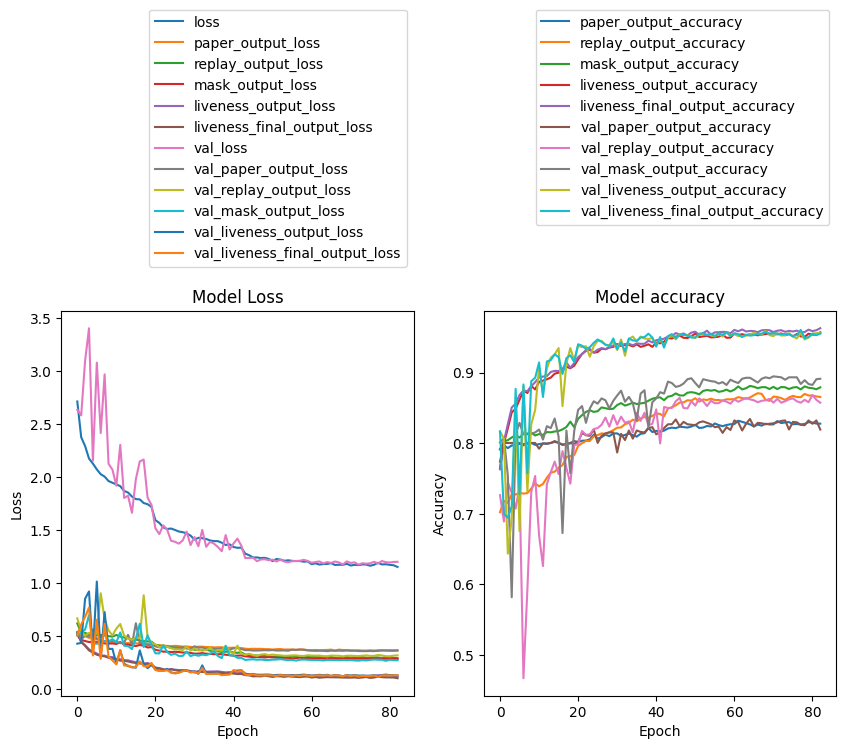

In [ ]:
loss_metrics = [x for x in history.history.keys() if 'loss' in x]
acc_metrics = [x for x in history.history.keys() if 'accuracy' in x]

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
for metric in loss_metrics:
    plt.plot(history.history[metric], label=metric)

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loss_metrics, bbox_to_anchor=(1.00, 1.80))

plt.subplot(1, 2, 2)
for metric in acc_metrics:
    plt.plot(history.history[metric], label=metric)

plt.title('Model accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(acc_metrics, bbox_to_anchor=(1.00, 1.80))

plt.show()

## Predict

### Val

In [ ]:
import tqdm
np.random.seed(42)
tf.random.set_seed(42)
no_times=25
for i in tqdm.tqdm(range(no_times), total=no_times):
   predict = np.array(model.predict(val_generator, verbose=1))[:,:,1:]


   if i==0:
       predict_test_array = predict.copy()
   else:
       predict_test_array = np.concatenate([predict_test_array, predict], axis=-1)

  0%|          | 0/25 [00:00<?, ?it/s]

47/47 [==============================] - 16s 293ms/step


  4%|▍         | 1/25 [00:16<06:29, 16.23s/it]

47/47 [==============================] - 12s 264ms/step


  8%|▊         | 2/25 [00:28<05:26, 14.18s/it]

...

 92%|█████████▏| 23/25 [04:53<00:25, 12.60s/it]

47/47 [==============================] - 12s 261ms/step


 96%|█████████▌| 24/25 [05:06<00:12, 12.60s/it]

47/47 [==============================] - 12s 261ms/step


100%|██████████| 25/25 [05:18<00:00, 12.76s/it]


In [ ]:
val['paper_pred'] = predict_test_array[0].tolist()
val['mask_pred'] = predict_test_array[1].tolist()
val['replay_pred'] = predict_test_array[2].tolist()
val['liveness_pred'] = predict_test_array[3].tolist()
val['liveness_final_pred'] = predict_test_array[4].tolist()
val.to_csv(f'/content/gdrive/MyDrive/PhD_Models/PhDresults/PhD2_protIntra_trCeAS_valCeAS_min.csv', index=False)
val.head(3)

<ipython-input-35-95fcb32998fa>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val['paper_pred'] = predict_test_array[0].tolist()
<ipython-input-35-95fcb32998fa>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val['mask_pred'] = predict_test_array[1].tolist()
<ipython-input-35-95fcb32998fa>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/p

,full_path_iqa,data_type,person,environment,illumination_condition,spoof_type,label,label_value,distortion_type,paper_label,mask_label,replay_label,liveness_label,liveness_final_label,paper_pred,mask_pred,replay_pred,liveness_pred,liveness_final_pred
2,Data/train/335/spoof/046171.jpg,val,335,1,1,1,spoof,1,335,"[1.0, 0.0]","[0.0, 1.0]","[0.0, 1.0]","[1.0, 0.0]","[1.0, 0.0]","[0.8313732743263245, 0.8218947649002075, 0.922...","[0.9655570387840271, 0.9313172101974487, 0.909...","[0.6566560864448547, 0.6833963990211487, 0.634...","[0.0825643539428711, 0.02942580170929432, 0.01...","[0.05457992106676102, 0.019252359867095947, 0...."
12,Data/train/159/spoof/069743.jpg,val,159,1,1,1,spoof,1,159,"[1.0, 0.0]","[0.0, 1.0]","[0.0, 1.0]","[1.0, 0.0]","[1.0, 0.0]","[0.5171874165534973, 0.5177823901176453, 0.332...","[0.3908970057964325, 0.5138604640960693, 0.357...","[0.9996194839477539, 0.9988266825675964, 0.999...","[0.07358162850141525, 0.01206099335104227, 0.0...","[0.0030367898289114237, 0.0006003858870826662,..."
16,Data/train/8079/spoof/413117.jpg,val,8079,2,2,8,spoof,1,8079,"[0.0, 1.0]","[0.0, 1.0]","[1.0, 0.0]","[1.0, 0.0]","[1.0, 0.0]","[0.7653706669807434, 0.8343126177787781, 0.842...","[0.8130983710289001, 0.856273353099823, 0.7686...","[0.3099465072154999, 0.4121752679347992, 0.264...","[8.539877308066934e-05, 0.00018026056932285428...","[6.323475099634379e-05, 0.0001676498504821211,..."


END